In [3]:
import pandas as pd
df = pd.read_csv("grades_crpt.csv")

## Data Exploration
#### **Look at basic stats, column names, and what the data looks like**

9 Columns & Their Names:
- A1-7
- Final_Exam
- user_id

The data looks like a database entry of each student's grade from their assingments and then the score of their final exam.

- The only column that isn't a floating number is the user_id


#### **Identify anything that stands out right away**

- Scores can go above 100
    - For example, user_id = U008 in A1 has a score of 168.9

- Scores can dip into the negatives (beyond 0)
    - For example, user_id = U068 has a score of -21.6 in A4
    - user_id = U013 has a score of -69.3 in A3

- There are many missing score entries across the assignments for many of the students



#### df.head() & info
Tells me the basic information of the data ex. column names and their entry.
- The head gives me the full information for the first 4 entries of the data


In [4]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


#### df.describe()

df.describe() helps me see the mean, median, min, and standard deviations of each data column
- it also gives me the lower pecentile (25%) and the upper percentile (75%)

- The count tells me how many non-null or missing data entries there are in the column

In [6]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


## Check the correlations

#### **Use a correlation matrix to find relationships between assignments and the final exam**



In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


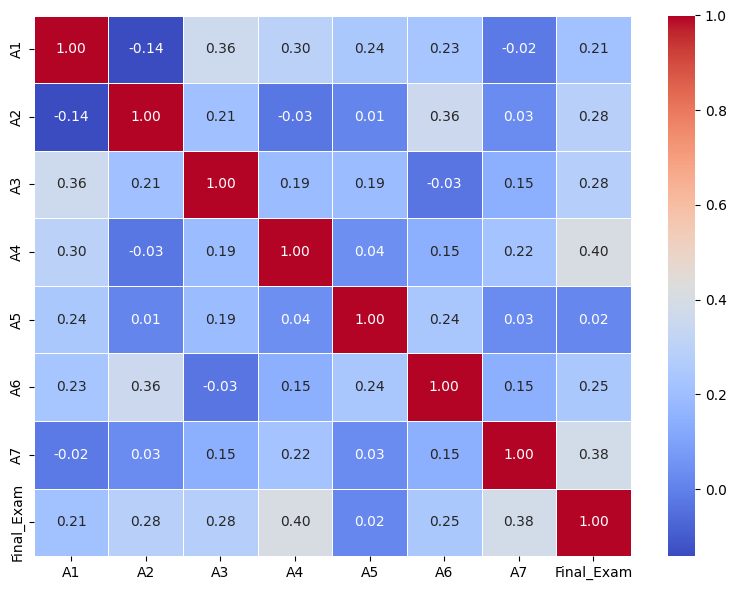

In [10]:
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# fmt=".2f" -> Two digits floating point
plt.tight_layout()
plt.show()

#### **Do any assignments seem strongly related to final exam performance?**
Based on the correlation matrixes:
- A4 has the strongest positive correlation with final exam score with 0.40
    - So as the score for A4 goes up, so does the score for the final exam.
    
- A5 seems to have the least correlation on the final exam score with a positive 0.02 only

### Assignment Choice Justification
**If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?


I decided to focus on the correlation between A1, A4, and the final exam. 
- This is because it most closely mimics the structure of a first exam (A1), midterm (A4), and then a final.

- Looking over the dataset as well, A1 and A4 have a large range of scores including 0 and negative scores

- A4 has been proven to have the strongest correlation with the final exam scores

**A4**: up to **5** bonus points


## Check for missing values

#### Which columns have them?
Based off the initial df.info(), all the columns except for the Final_Exam and user_id columns have values missing


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


#### How many are missing?
As there are supposed to be 86 total entries, that means:
- **A1:** 29 missing
- **A2:** 25 missing
- **A3:** 24 missing
- **A4:** 9 missing
- **A5:** 25 missing
- **A6:** 19 missing
- **A7:** 10 missing

## Handle the missing values
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?


#### Data Cleaning
First, I will created a copy of the dataframe to focus on A1, A4, and Final_Exam

In [22]:
df_converted = df.drop(columns=['A2', 'A3', 'A5', 'A6', 'A7'])

numeric_cols = ['A1', 'A4', 'Final_Exam']
corr_matrix = df_converted[numeric_cols].corr()

print(corr_matrix.round(2))

              A1   A4  Final_Exam
A1          1.00  0.3        0.21
A4          0.30  1.0        0.40
Final_Exam  0.21  0.4        1.00


Then I will convert any negative scores to 0, that way when I do mean and median calculations it won't create outliers and give me a more accurate average.
- Negative scores will be treated equivalent to 0 in this case.

I used this Stack to help me clip the lowest score to 0:
https://stackoverflow.com/questions/68929284/how-to-replace-nan-and-negative-number-with-zero

In [ ]:
df_converted[['A1', 'A4']] = df_converted[['A1', 'A4']].clip(lower=0) 

#Since I know entry 67 for A4 has a negative score, I'll double check that it worked with that entry
#If the entry for 67 in A4 is 0, I know it worked.
df_converted.head(68)

,A1,A4,Final_Exam,user_id
0,NaN,75.0,68.8,U001
1,100.0,92.5,50.3,U002
2,75.0,86.2,67.8,U003
3,25.0,0.0,0.0,U004
4,0.0,0.0,0.0,U005
...,...,...,...,...
63,NaN,81.0,42.8,U064
64,75.8,85.0,33.4,U065
65,95.8,NaN,35.6,U066
66,NaN,95.0,52.5,U067


#### Try out different imputation strategies (mean, median, remove, etc.)


## Check for outliers
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results
